# Week 4 workshop · Rules, states, consequences

## Workshop focus

The lecture and Reader introduce cellular automata. Here you will actively reconstruct and test them by:

- decoding a Wolfram rule number into local transitions;
- implementing and testing a synchronous update;
- comparing rules under controlled initial and boundary conditions;
- challenging density, recent activity, and neighbour disagreement as descriptions of visual structure;
- implementing Conway's Game of Life and testing it against known still lifes,
  oscillators, and spaceships.


# From the lecture to the workshop

The lecture moves from elementary cellular automata to Conway's Game of Life, then asks how cellular automata can be compared and classified. We begin in one dimension so that every neighbourhood and update can be inspected, then carry the same modelling choices into a two-dimensional world.

Rule 90 links back to the Sierpiński triangle from Week 2. Rule 110 supplies persistent structure, and Rule 204 gives a useful counterexample when we test proposed summary statistics. The same modelling choices carry into Game of Life: state, neighbourhood, boundary, initial condition, and update schedule.

**Canonical models used here:** elementary cellular automata and Conway's Game of Life.

This notebook needs Python 3.10 or later, NumPy, Matplotlib, and IPython. It does not need the lecture repository or any separate data or image files. Run the cells in order from a fresh kernel before beginning an extension.


In [1]:
from typing import Sequence

import json
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display

SEED = 3024
INK = "#1B2A4C"
BLUE = "#5879AA"
YELLOW = "#EDCC55"

rng = np.random.default_rng(SEED)
print(f"NumPy {np.__version__} · seed {SEED}")


NumPy 2.4.2 · seed 3024


# Elementary cellular automaton

| Ingredient | Workshop choice |
|---|---|
| World | A one-dimensional lattice |
| State | Each cell is 0 or 1 |
| Neighbourhood | Left, centre, and right cells |
| Boundary | Periodic wrap-around |
| Dynamics | One deterministic rule applied synchronously |
| Initial condition | A single central cell or a reproducible random state |
| Clock | One simultaneous update of every cell |

> **Modelling choice:** State, neighbourhood, boundary, initialisation, and update schedule are separate choices.


Three binary cells form eight possible neighbourhoods. Reading $111,110,\ldots,000$ as binary numbers gives indices $7,6,\ldots,0$.

Rule 90 is

$$90=01011010_2.$$

The bit at index $n$ gives the output for the neighbourhood whose binary value is $n$.


In [2]:
def rule_table(rule: int) -> np.ndarray:
    """Return outputs indexed by neighbourhood values 0,...,7."""
    if not isinstance(rule, (int, np.integer)) or not 0 <= rule <= 255:
        raise ValueError("rule must be an integer from 0 to 255")
    return np.array([(rule >> index) & 1 for index in range(8)], dtype=np.uint8)


def neighbourhood_bits(value: int) -> tuple[int, int, int]:
    """Return the left, centre, and right bits encoded by a value from 0 to 7."""
    if not isinstance(value, (int, np.integer)) or not 0 <= value <= 7:
        raise ValueError("value must be an integer from 0 to 7")
    return (value >> 2 & 1, value >> 1 & 1, value & 1)


assert np.array_equal(rule_table(90), [0, 1, 0, 1, 1, 0, 1, 0])
assert neighbourhood_bits(6) == (1, 1, 0)

rule = 90
table = rule_table(rule)
for value in range(7, -1, -1):
    print("".join(map(str, neighbourhood_bits(value))), "→", table[value])


111 → 0
110 → 1
101 → 0
100 → 1
011 → 1
010 → 0
001 → 1
000 → 0


> **Discuss:** For Rule 90, which part of the neighbourhood determines the next state? Does the centre matter?

Rule 90 outputs one exactly when the left and right states differ. It is the exclusive-or of the two neighbours.


## Apply one synchronous update

All outputs must be calculated from the same previous state. Updating cells in place from left to right would define a different, asynchronous model.


In [3]:
def validate_state(state: np.ndarray) -> np.ndarray:
    """Validate and return a one-dimensional binary state array."""
    state = np.asarray(state)
    if state.ndim != 1 or state.size < 1:
        raise ValueError("state must be a non-empty one-dimensional array")
    if not np.all((state == 0) | (state == 1)):
        raise ValueError("state must contain only zeros and ones")
    return state.astype(np.uint8, copy=False)


def elementary_ca_step(state: np.ndarray, rule: int) -> np.ndarray:
    """Apply one synchronous elementary-CA update with periodic boundaries."""
    state = validate_state(state)
    left = np.roll(state, 1)
    right = np.roll(state, -1)
    neighbourhood_value = 4 * left + 2 * state + right
    return rule_table(rule)[neighbourhood_value]


## Test rules whose behaviour is known

Tests make the bit ordering and periodic boundary convention explicit.


In [4]:
test_state = np.array([0, 1, 1, 0, 1], dtype=np.uint8)

assert np.array_equal(elementary_ca_step(test_state, 0), np.zeros_like(test_state))
assert np.array_equal(elementary_ca_step(test_state, 255), np.ones_like(test_state))
assert np.array_equal(elementary_ca_step(test_state, 204), test_state)  # identity rule
assert np.array_equal(
    elementary_ca_step(test_state, 90),
    np.bitwise_xor(np.roll(test_state, 1), np.roll(test_state, -1)),
)
assert np.array_equal(test_state, [0, 1, 1, 0, 1])  # input was not mutated

print("All one-step tests passed.")


All one-step tests passed.


## Iterate the rule

The returned history includes the initial state at time zero. Rows are time steps and columns are cells.


In [5]:
def simulate_elementary_ca(
    initial_state: np.ndarray,
    rule: int,
    steps: int,
) -> np.ndarray:
    """Return a state history with shape `(steps + 1, n_cells)`."""
    state = validate_state(initial_state).copy()
    if not isinstance(steps, (int, np.integer)) or steps < 0:
        raise ValueError("steps must be a non-negative integer")
    history = np.empty((steps + 1, state.size), dtype=np.uint8)
    history[0] = state
    for time in range(1, steps + 1):
        state = elementary_ca_step(state, rule)
        history[time] = state
    return history


def single_seed(n_cells: int) -> np.ndarray:
    if not isinstance(n_cells, (int, np.integer)) or n_cells < 1:
        raise ValueError("n_cells must be a positive integer")
    state = np.zeros(n_cells, dtype=np.uint8)
    state[n_cells // 2] = 1
    return state


def random_state(n_cells: int, density: float, rng: np.random.Generator) -> np.ndarray:
    if n_cells < 1 or not 0 <= density <= 1:
        raise ValueError("n_cells must be positive and density must lie in [0,1]")
    return (rng.random(n_cells) < density).astype(np.uint8)


## Pause one process

Use play/pause and the slider to inspect Rule 110 one synchronous update at a time.


In [6]:
def ca_player(history: np.ndarray, element_id: str = "ca-player") -> HTML:
    """Return a dependency-free player for a one-dimensional CA history."""
    history = np.asarray(history, dtype=np.uint8)
    data = json.dumps(history.tolist())
    return HTML(f"""
    <div id="{element_id}" style="font-family:Arial,sans-serif;color:#1B2A4C">
      <canvas width="1000" height="90" style="width:100%;border:1px solid #C7CEDC;image-rendering:pixelated"></canvas>
      <div style="display:flex;gap:12px;align-items:center;margin-top:8px">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(history)-1}" value="0" style="flex:1;accent-color:#1B2A4C">
        <span></span>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}'), states={data};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button'), label=root.querySelector('span');
      let timer=null;
      function draw(k) {{
        const state=states[k], width=canvas.width/state.length;
        state.forEach((value,j)=>{{ctx.fillStyle=value?'#1B2A4C':'#ffffff';ctx.fillRect(j*width,0,width+.5,canvas.height);}});
        label.textContent=`t = ${{k}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=states.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},180);}};
      slider.oninput=()=>draw(+slider.value); draw(0);
    }})();
    </script>
    """)


player_initial = random_state(240, density=0.5, rng=np.random.default_rng(SEED))
history_110 = simulate_elementary_ca(player_initial, rule=110, steps=160)
display(ca_player(history_110))


That wasn't very helpful or informative. Much better to show time as the second dimension in this case.

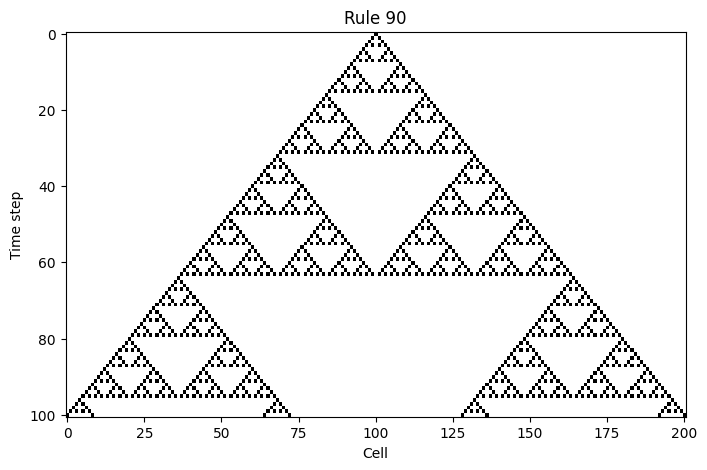

In [7]:
def plot_history(history: np.ndarray, rule: int, ax=None, title: str | None = None):
    """Plot time vertically and cells horizontally."""
    if ax is None:
        _, ax = plt.subplots(figsize=(8, 5))
    ax.imshow(history, cmap="binary", vmin=0, vmax=1, interpolation="nearest", aspect="auto")
    ax.set(xlabel="Cell", ylabel="Time step", title=title or f"Rule {rule}")
    return ax


initial_single = single_seed(201)
history_90 = simulate_elementary_ca(initial_single, rule=90, steps=100)
plot_history(history_90, rule=90)
plt.show()


The vertical direction in this image is time, not a second spatial dimension.

## Compare rules fairly

Changing both the rule and the random initial state prevents us from attributing differences to the rule. Generate one initial state, then reuse it.

> **Discuss:** Predict which rule will become uniform, periodic, nested, or persistently irregular.


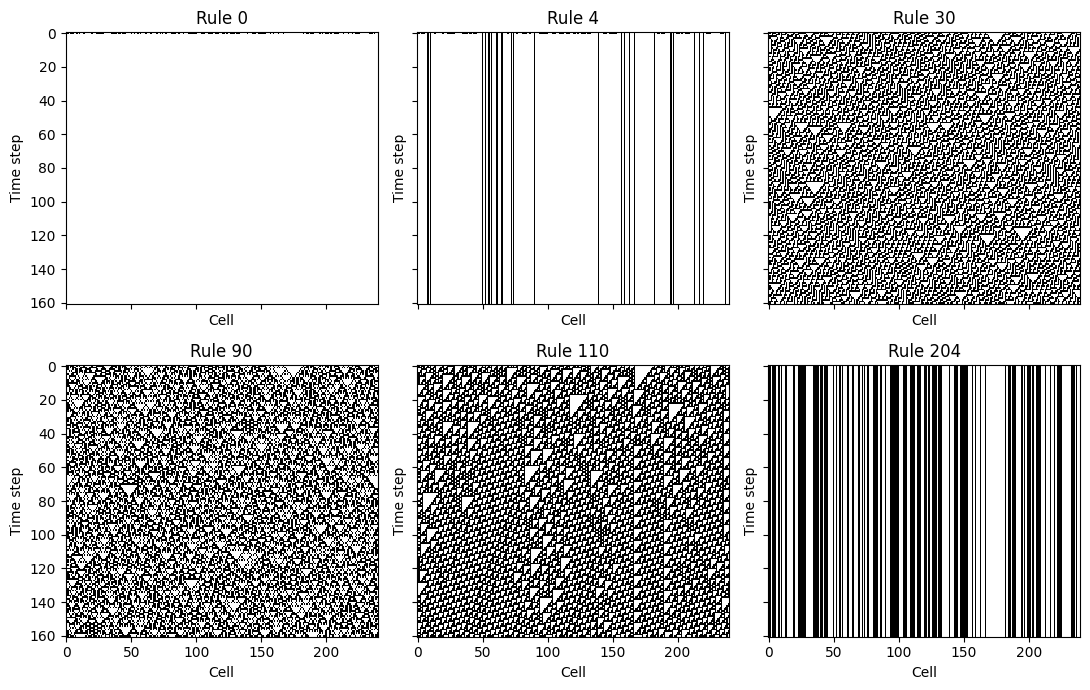

In [8]:
shared_initial = random_state(240, density=0.5, rng=np.random.default_rng(SEED))
rules = [0, 4, 30, 90, 110, 204]

fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
for ax, rule in zip(axes.flat, rules):
    history = simulate_elementary_ca(shared_initial, rule, steps=160)
    plot_history(history, rule, ax=ax)
fig.tight_layout()
plt.show()


## Small periodic worlds change the neighbourhood

With only three cells, the left and right neighbours of a focal cell are the same two sites in opposite order. With two cells, left and right refer to the same site. The code still runs, but the intended three-cell neighbourhood has collapsed.

> **Discuss:** What is the smallest periodic world in which left, centre, and right are three distinct sites?


In [9]:
for n_cells in [2, 3, 4]:
    labels = np.arange(n_cells)
    focal = 0
    neighbourhood = (labels[(focal - 1) % n_cells], labels[focal], labels[(focal + 1) % n_cells])
    print(f"n={n_cells}: focal-site neighbourhood labels = {neighbourhood}")


n=2: focal-site neighbourhood labels = (np.int64(1), np.int64(0), np.int64(1))
n=3: focal-site neighbourhood labels = (np.int64(2), np.int64(0), np.int64(1))
n=4: focal-site neighbourhood labels = (np.int64(3), np.int64(0), np.int64(1))


## Quantitative views

For a binary state $x$:

- **density** $\rho=\langle x\rangle$ is the fraction of cells in state one;
- **binary entropy** $H(\rho)$ measures uncertainty in the state of a randomly sampled cell;
- **activity** is the fraction of cells that change between consecutive steps.

These compress different features. None is a complete measure of spatial complexity.


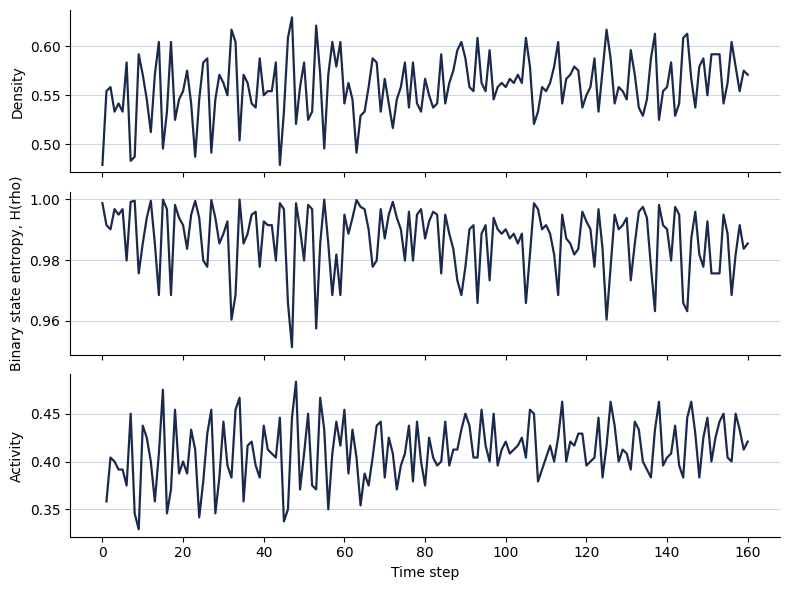

In [10]:
def binary_entropy_from_density(density: np.ndarray) -> np.ndarray:
    """Binary Shannon entropy in bits, with 0 log 0 defined as zero."""
    density = np.asarray(density, dtype=float)
    if np.any((density < 0) | (density > 1)):
        raise ValueError("density must lie in [0,1]")
    entropy = np.zeros_like(density)
    interior = (density > 0) & (density < 1)
    p = density[interior]
    entropy[interior] = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    return entropy


def ca_observables(history: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return density, binary state entropy, and between-step activity."""
    history = np.asarray(history)
    density = history.mean(axis=1)
    entropy = binary_entropy_from_density(density)
    activity = np.r_[np.nan, np.mean(history[1:] != history[:-1], axis=1)]
    return density, entropy, activity


density, entropy, activity = ca_observables(history_110)
fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
for ax, values, label in zip(axes, (density, entropy, activity), ("Density", "Binary state entropy, H(rho)", "Activity")):
    ax.plot(values, color=INK, linewidth=1.6)
    ax.set_ylabel(label)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#C7CEDC", linewidth=0.6)
axes[-1].set_xlabel("Time step")
fig.tight_layout()
plt.show()


> **Discuss:** Can a static configuration and a rapidly changing configuration have the same density and binary state entropy? Which observable notices the difference?

Rule 204 is a useful counterexample: it can retain high binary state entropy while having zero activity after initialisation. Here $H(\rho)$ is calculated directly from density, so it is not an independent measure of spatial organisation. Entropy and information measures are developed properly in Week 9.


## A deliberately lossy map of rule space

Apply every rule to a small ensemble of random initial states. For each run, summarise the final 40 steps using three deliberately simple observables:

- **late-time density:** the fraction of cells in state one;
- **late-time activity:** the fraction changing state between steps;
- **neighbour disagreement:** the fraction of adjacent pairs in different states.

The plot moves up the ladder by replacing each complete history with three numbers. It is a map of finite experiments, not a universal classification of the rules.


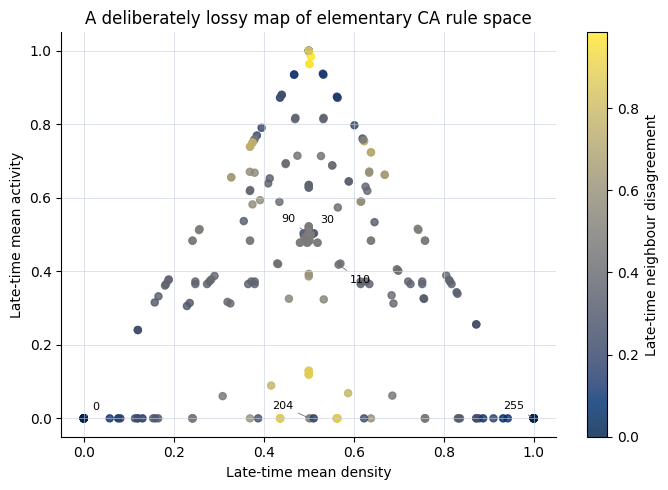

In [11]:
def neighbour_disagreement(state: np.ndarray) -> float:
    """Fraction of adjacent pairs that differ, using the periodic boundary."""
    state = np.asarray(state)
    return float(np.mean(state != np.roll(state, 1)))


n_initial_states = 6
late_window = 40
initial_rng = np.random.default_rng(SEED + 1)
initial_states = [random_state(240, density=0.5, rng=initial_rng) for _ in range(n_initial_states)]

summary = []
for rule in range(256):
    run_summaries = []
    for initial_state in initial_states:
        history = simulate_elementary_ca(initial_state, rule, steps=160)
        density, _, activity = ca_observables(history)
        disagreement = np.array([neighbour_disagreement(state) for state in history])
        run_summaries.append((
            np.mean(density[-late_window:]),
            np.nanmean(activity[-late_window:]),
            np.mean(disagreement[-late_window:]),
        ))
    summary.append((rule, *np.mean(run_summaries, axis=0)))

summary = np.asarray(summary)
fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    summary[:, 1], summary[:, 2], c=summary[:, 3], cmap="cividis", s=26, alpha=0.82
)
label_offsets = {0: (6, 6), 30: (8, 8), 90: (-20, 9), 110: (8, -13), 204: (-27, 7), 255: (-22, 7)}
for rule, offset in label_offsets.items():
    row = summary[rule]
    ax.annotate(
        str(rule), row[1:3], xytext=offset, textcoords="offset points",
        fontsize=8, arrowprops={"arrowstyle": "-", "color": "#667085", "lw": 0.6},
    )
ax.set(
    xlabel="Late-time mean density",
    ylabel="Late-time mean activity",
    title="A deliberately lossy map of elementary CA rule space",
)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#C7CEDC", linewidth=0.6, alpha=0.7)
fig.colorbar(scatter, ax=ax, label="Late-time neighbour disagreement")
fig.tight_layout()
plt.show()


> **The ladder of abstraction:** **Up the ladder:** one local rule → an ensemble of histories → three observables → a finite survey of rule space.

> **Discuss:** Find two visibly different histories that lie near one another in this map. What information did density, activity, and neighbour disagreement discard?

The survey depends on lattice size, boundary condition, initial-condition ensemble, runtime, averaging window, and chosen observables. A different experiment can move a rule elsewhere in this plot. Neighbour disagreement notices local alternation, but it still cannot distinguish all spatial structures. Week 9 develops entropy and information-based measures that can describe structure more carefully.


# Conway's Game of Life

Game of Life keeps binary states and synchronous updates, but moves to a
two-dimensional square lattice. Each cell reads its eight-cell **Moore
neighbourhood**.

| Ingredient | Workshop choice |
|---|---|
| World | A two-dimensional square lattice |
| State | Dead (0) or alive (1) |
| Neighbourhood | Eight surrounding cells; the focal cell is not counted |
| Boundary | Periodic wrap-around for the baseline |
| Update | Synchronous B3/S23 rule |

**B3/S23** means that a dead cell is **born** with exactly three live
neighbours, while a live cell **survives** with two or three. Every other cell
is dead in the next state.


In [12]:
def validate_life_grid(grid: np.ndarray) -> np.ndarray:
    """Validate and return a two-dimensional binary grid."""
    grid = np.asarray(grid)
    if grid.ndim != 2 or min(grid.shape) < 1:
        raise ValueError("grid must be a non-empty two-dimensional array")
    if not np.all((grid == 0) | (grid == 1)):
        raise ValueError("grid must contain only zeros and ones")
    return grid.astype(np.uint8, copy=False)


def moore_neighbour_count(grid: np.ndarray) -> np.ndarray:
    """Count live Moore neighbours using periodic boundaries."""
    grid = validate_life_grid(grid)
    count = np.zeros_like(grid, dtype=np.uint8)
    for row_shift in (-1, 0, 1):
        for col_shift in (-1, 0, 1):
            if row_shift == 0 and col_shift == 0:
                continue
            count += np.roll(grid, shift=(row_shift, col_shift), axis=(0, 1))
    return count


def game_of_life_step(grid: np.ndarray) -> np.ndarray:
    """Apply one synchronous B3/S23 update with periodic boundaries."""
    grid = validate_life_grid(grid)
    neighbours = moore_neighbour_count(grid)
    born = (grid == 0) & (neighbours == 3)
    survives = (grid == 1) & ((neighbours == 2) | (neighbours == 3))
    return (born | survives).astype(np.uint8)


def simulate_game_of_life(initial_grid: np.ndarray, steps: int) -> np.ndarray:
    """Return a Game-of-Life history including the initial configuration."""
    grid = validate_life_grid(initial_grid).copy()
    if not isinstance(steps, (int, np.integer)) or steps < 0:
        raise ValueError("steps must be a non-negative integer")
    history = np.empty((steps + 1, *grid.shape), dtype=np.uint8)
    history[0] = grid
    for time in range(1, steps + 1):
        grid = game_of_life_step(grid)
        history[time] = grid
    return history


## Test the rule using known objects

A visual resemblance is not enough to validate the code. Still lifes,
oscillators and spaceships provide executable checks with known periods and
motions.


In [13]:
def place_pattern(shape: tuple[int, int], pattern: np.ndarray, top: int, left: int) -> np.ndarray:
    """Place a binary pattern on an otherwise empty periodic grid."""
    grid = np.zeros(shape, dtype=np.uint8)
    pattern = validate_life_grid(pattern)
    rows, cols = pattern.shape
    if top < 0 or left < 0 or top + rows > shape[0] or left + cols > shape[1]:
        raise ValueError("pattern must fit inside the grid")
    grid[top:top + rows, left:left + cols] = pattern
    return grid


BLOCK = np.array([[1, 1], [1, 1]], dtype=np.uint8)
BLINKER = np.array([[1, 1, 1]], dtype=np.uint8)
GLIDER = np.array([[0, 1, 0],
                   [0, 0, 1],
                   [1, 1, 1]], dtype=np.uint8)

block = place_pattern((12, 12), BLOCK, 5, 5)
assert np.array_equal(game_of_life_step(block), block)

blinker = place_pattern((12, 12), BLINKER, 5, 4)
assert not np.array_equal(game_of_life_step(blinker), blinker)
assert np.array_equal(simulate_game_of_life(blinker, 2)[-1], blinker)

glider = place_pattern((20, 20), GLIDER, 5, 5)
after_four = simulate_game_of_life(glider, 4)[-1]
assert np.array_equal(after_four, np.roll(glider, shift=(1, 1), axis=(0, 1)))

print("Block, blinker, and glider tests passed.")


Block, blinker, and glider tests passed.


## Inspect a two-dimensional trajectory

Time can no longer be displayed as a second plotting axis because both axes
already represent space. Use snapshots or an animation, but retain direct
control of time so that individual updates can still be inspected.


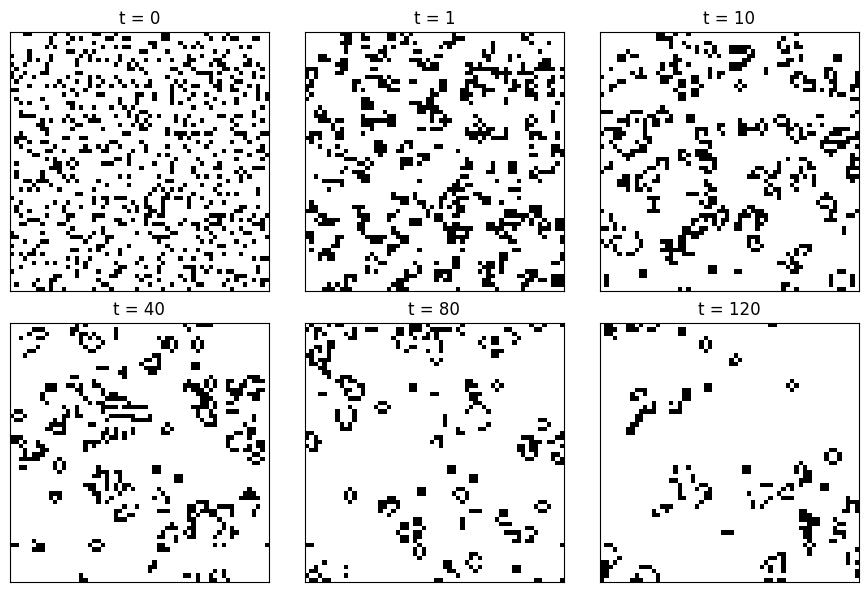

In [14]:
life_rng = np.random.default_rng(SEED)
life_initial = (life_rng.random((60, 60)) < 0.20).astype(np.uint8)
life_history = simulate_game_of_life(life_initial, steps=120)

snapshot_times = [0, 1, 10, 40, 80, 120]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, time in zip(axes.flat, snapshot_times):
    ax.imshow(life_history[time], cmap="binary", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"t = {time}")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()
plt.show()


In [15]:
def life_player(history: np.ndarray, element_id: str = "life-player") -> HTML:
    """Return a dependency-free player for a Game-of-Life history."""
    history = np.asarray(history, dtype=np.uint8)
    if history.ndim != 3:
        raise ValueError("history must have shape (time, rows, columns)")
    data = json.dumps(history.tolist())
    return HTML(f"""
    <div id="{element_id}" style="font-family:Arial,sans-serif;color:#1B2A4C;max-width:720px">
      <canvas width="600" height="600" style="width:min(100%,560px);border:1px solid #C7CEDC;image-rendering:pixelated"></canvas>
      <div style="display:flex;gap:12px;align-items:center;margin-top:8px">
        <button type="button">Play</button>
        <input type="range" min="0" max="{len(history)-1}" value="0" style="flex:1;accent-color:#1B2A4C">
        <span></span>
      </div>
    </div>
    <script>
    (() => {{
      const root=document.getElementById('{element_id}'), states={data};
      const canvas=root.querySelector('canvas'), ctx=canvas.getContext('2d');
      const slider=root.querySelector('input'), button=root.querySelector('button'), label=root.querySelector('span');
      let timer=null;
      function draw(k) {{
        const state=states[k], rows=state.length, cols=state[0].length;
        const w=canvas.width/cols, h=canvas.height/rows;
        ctx.fillStyle='#ffffff'; ctx.fillRect(0,0,canvas.width,canvas.height);
        ctx.fillStyle='#1B2A4C';
        state.forEach((row,i)=>row.forEach((value,j)=>{{if(value)ctx.fillRect(j*w,i*h,w+.5,h+.5);}}));
        label.textContent=`t = ${{k}}`;
      }}
      function stop() {{clearInterval(timer);timer=null;button.textContent='Play';}}
      button.onclick=()=>{{if(timer){{stop();return;}}button.textContent='Pause';timer=setInterval(()=>{{let k=+slider.value;if(k>=states.length-1){{stop();return;}}slider.value=k+1;draw(k+1);}},140);}};
      slider.oninput=()=>draw(+slider.value); draw(0);
    }})();
    </script>
    """)


display(life_player(life_history))


## Investigate the two-dimensional model

1. Replace the random state with a block, blinker, glider, or another documented pattern. Does the observed period or displacement match the test?
2. Replace periodic boundaries with fixed-dead boundaries. Which objects distinguish the two choices, and how long must they run before the difference is visible?
3. Compare several random initial densities using the same grid size and runtime. Record live-cell density and activity through time rather than judging only the final picture.
4. Find a small seed with a long transient. Define the event that marks the end of the transient before comparing seeds.
5. Add one morphology-aware observable, such as connected-component count, cluster-size distribution, perimeter, or a box-counting estimate. State what spatial feature it retains that density discards.

> **Modelling choice:** A larger neighbourhood, an asynchronous clock, or a different boundary does not merely tune Conway's model; it defines a different cellular automaton.


# Choose an extension

## A · Change the update schedule

Implement asynchronous updates. Compare with the synchronous baseline using the same rule and initial state.

## B · Change the boundary

Implement fixed-zero or reflecting boundaries. Construct a test that distinguishes them from periodic boundaries.

## C · Challenge an observable

Add block entropy, compressibility, mutual information, or a spatial transition count. Find two histories your measure separates.

## D · Test robustness

Repeat selected rules over an ensemble of initial states and lattice sizes. Which conclusions survive?


In [16]:
# Your extension goes here. Keep the baseline functions unchanged where possible.


# Exit ticket

In four sentences:

1. Decode one neighbourhood transition from a rule number.
2. Name one boundary or update-schedule choice.
3. Describe one system-level observable.
4. Explain one reason a visual or numerical classification may not generalise.
